In [4]:
import os
# os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

# from vllm import LLM, SamplingParams
# llm = LLM(model="google/gemma-3-12b-it")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# drive.mount('/content/drive', force_remount=True)
# !cp -r /content/drive/MyDrive/huggingface_cache /content/huggingface_cache
# !cp -r /content/huggingface_cache /content/drive/MyDrive/huggingface_cache

cache_path = "/content/huggingface_cache"
os.makedirs(cache_path, exist_ok=True)
os.environ['HF_HOME'] = cache_path

# Research Plan
As the dataset is particularly large (~20k) rows and very heavily imbalanced (see below), we opted for the following course-of-action:
1. Split the set into train/test with a 50/50 split. This gives a sizable amount of training and test data, but more so matches the previous study predicting Human Factors. In that, they didn't train, they just used GPT-3.5 Flash on a dataset of ~10K rows. Hence we opt for a test size of similar magnitude.
2. Split the train set into a smaller, more balanced set using downsampling. This allows us to get a rough upfront estimate of model performance on each category upfront, avoiding long inference times & fiscal costs.

## Load & Split Dataset

In [2]:
df = pd.read_csv("narratives.csv", index_col=0)
df

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative
2260174,ambiguous,Aircraft vectored in within 1NM to final appro...,NaN
2260249,ambiguous,While on short final we received a glideslope ...,NaN
2260370,aircraft,Flying at cruise; FL350; the FO was the PF and...,At cruise; FL350; during level-off; the Captai...
2261277,humanfactors,On Day 0 around XA:30; I forgot to get LAANC a...,NaN
2261317,procedure,Divert into ZZZ from ZZZ1. FO flying. Vectors ...,Extremely strong winds blew us off the LOC whi...
...,...,...,...
1855349,mel,To start out; this was an embarrassing and ine...,NaN
1855355,humanfactors,We were on a night ILS 13 approach at MDT with...,I was pilot flying. We were cleared to land by...
1855375,aircraft,After a normal landing in ZZZZ I started the A...,NaN
1855376,aircraft,On the descent into ZZZ1 on Aircraft X from ZZ...,NaN


In [3]:
from sklearn.model_selection import train_test_split

def split_set(df:pd.DataFrame, target:str="Assessments_Primary_Problem"):
  assert target in df.columns

  X = df[[col for col in df.columns if col != target]]
  y = df[target]

  return X, y

def make_balanced(X:pd.DataFrame, y:pd.Series, downsample_to_freq:int):
  """
  Accepts an X,y and selects at most `downsample_to_freq` instances for each label in y
  or just uses all instances for label if count(instances w/ label) < downsample_to_freq.
  """
  c = y.name
  df = pd.merge(X, y, left_index=True, right_index=True)
  li = []

  for cat in y.unique():
    matched = df[df[c] == cat]
    li.append(matched.head(downsample_to_freq))

  res = pd.concat(li)
  res = res.sample(frac=1, random_state=42) # shuffle
  res.to_csv("balanced.csv")
  return split_set(res, c)

X, y = split_set(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.5)

print("Target is heavily imbalanced:")
display(y_train.value_counts(normalize=True))

print("So we downsample to for running preliminary trials on models: ")
bX, by = make_balanced(X_train, y_train, downsample_to_freq=100)
display(by.value_counts(normalize=True))

Target is heavily imbalanced:


,proportion
Assessments_Primary_Problem,
humanfactors,0.367297
aircraft,0.276565
procedure,0.100922
environment-nonweatherrelated,0.057254
ambiguous,0.054828
weather,0.032508
airport,0.023290
chartorpublication,0.022319
atcequipment/navfacility/buildings,0.016497


So we downsample to for running preliminary trials on models: 


,proportion
Assessments_Primary_Problem,
ambiguous,0.125786
humanfactors,0.125786
procedure,0.125786
environment-nonweatherrelated,0.125786
aircraft,0.125786
weather,0.084277
airport,0.060377
chartorpublication,0.057862
atcequipment/navfacility/buildings,0.042767


## Setup Prompting

In [4]:
# from transformers import pipeline, AutoTokenizer

sys_prompt = """You are an expert aviation analyst categorizing incident reports according to their primary problem using the following 18 categories:
- Aircraft
- Airport
- Airspace Structure
- ATC Equipment / Nav Facility / Buildings
- Chart or Publication
- Company Policy
- Equipment / Tooling
- Environment (Non-Weather Related)
- Human Factors
- Incorrect / Not Installed / Unavailable Part
- Logbook Entry
- Manuals
- MEL
- Procedure
- Software and Automation
- Staffing
- Weather
- Ambiguous
"""

prompt_base = """
Consider this incident report narrative. Choose and return exactly one of the primary problem category.
Report Number: {1}
Report:
{0}

Return the primary problem using the categories above and a brief 1-2 sentence rationale, explaining the reasoning behind your choice by citing specific details from the report.
You MUST always return your answer in the following form:
Explanation: (the reason for the label you choose)
Primary Problem: (the chosen label for this incident)
"""

def format_narratives(narratives:list[str], acn:str) -> str:
  narrative_string = "\n".join([f"Narrative {idx+1} - '{narratives[idx]}'" for idx in range(len(narratives)) if pd.notna(narratives[idx])])
  return prompt_base.format(narrative_string, acn)

def make_message_prompt(narratives:list[str], acn:str):
  return [
    {"role": "system", "content": sys_prompt}, {"role": "user", "content": format_narratives(narratives, acn)}
  ]

def make_autocomplete_prompt(narratives:list[str], acn:str):
  return f"{sys_prompt} - {format_narratives(narratives, acn)}"

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from typing import Callable

def make_prompts(df:pd.DataFrame, prompt_maker: Callable):

  res = df[df.columns].apply(
      lambda x: prompt_maker(x.to_list(), acn=x.name),
      axis=1
  )
  return pd.DataFrame(res, columns=['prompt'])


prompt_pipe = FunctionTransformer(make_prompts, kw_args={"prompt_maker" : make_message_prompt})
prompt_pipe.fit_transform(bX)

,prompt
1831059,"[{'role': 'system', 'content': 'You are an exp..."
1785284,"[{'role': 'system', 'content': 'You are an exp..."
1845740,"[{'role': 'system', 'content': 'You are an exp..."
1852195,"[{'role': 'system', 'content': 'You are an exp..."
1816677,"[{'role': 'system', 'content': 'You are an exp..."
...,...
1855033,"[{'role': 'system', 'content': 'You are an exp..."
1817205,"[{'role': 'system', 'content': 'You are an exp..."
1832044,"[{'role': 'system', 'content': 'You are an exp..."
1844673,"[{'role': 'system', 'content': 'You are an exp..."


## Inference

### Gemma 3 12b-it Trials

#### Inference (old)

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [8]:
import torch
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model="google/gemma-3-12b-it",
    device_map="auto",
    dtype=torch.bfloat16,
)


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [9]:
chats = prompt_pipe.fit_transform(bX)['prompt'].values.tolist()
chats[-1]

[{'role': 'system',
  'content': 'You are an expert aviation analyst categorizing incident reports according to their primary problem using the following 18 categories:\n- Aircraft\n- Airport\n- Airspace Structure\n- ATC Equipment / Nav Facility / Buildings\n- Chart or Publication\n- Company Policy\n- Equipment / Tooling\n- Environment (Non-Weather Related)\n- Human Factors\n- Incorrect / Not Installed / Unavailable Part\n- Logbook Entry\n- Manuals\n- MEL\n- Procedure\n- Software and Automation\n- Staffing\n- Weather\n- Ambiguous\n'},
 {'role': 'user',
  'content': "\nConsider this incident report narrative. Choose and return exactly one of the primary problem category.\nReport Number: 1800416\nReport:\nNarrative 1 - 'It was a very busy day coming into DAL. We were being vectored from the northeast for a Visual Approach. We had Company traffic in sight and were told to follow them and cleared for the Visual Approach. We ensured clearance from them and began maneuvering for the runway w

In [12]:
results = pipe(chats, max_length=2_500, max_new_tokens=80, batch_size=8)

Both `max_new_tokens` (=80) and `max_length`(=2500) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2500) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2500) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2500) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [14]:
results

[[{'generated_text': [{'role': 'system',
     'content': 'You are an expert aviation analyst categorizing incident reports according to their primary problem using the following 18 categories:\n- Aircraft\n- Airport\n- Airspace Structure\n- ATC Equipment / Nav Facility / Buildings\n- Chart or Publication\n- Company Policy\n- Equipment / Tooling\n- Environment (Non-Weather Related)\n- Human Factors\n- Incorrect / Not Installed / Unavailable Part\n- Logbook Entry\n- Manuals\n- MEL\n- Procedure\n- Software and Automation\n- Staffing\n- Weather\n- Ambiguous\n'},
    {'role': 'user',
     'content': "\nConsider this incident report narrative. Choose and return exactly one of the primary problem category.\nReport Number: 1831059\nReport:\nNarrative 1 - 'Once again the PAPIs at PTKK are inoperative.  There should be a Company response to lack of electronic/ visual glidepath for night operations.'\n\nReturn the primary problem using the categories above and a brief 1-2 sentence rationale, expl

In [15]:
import json

with open("output_1.json", "w") as json_file:
  json.dump(results, json_file, indent=2)

In [16]:
pred = []
for output in results:
    text= output[0]['generated_text']
    report_line = text.rfind("Report Number:") + len("Report Number:")
    idx = text.rfind("Problem:") + len("Problem:")
    label = text[idx:].replace("\n", "")
    print(label)
    pred.append(label)

pred = pd.Series(pred)
# for output in results:
#     print(output[0]['generated_text'][-1]['content'])

AttributeError: 'list' object has no attribute 'rfind'

In [25]:
pred

,0
0,<primary problem> Return to Service (ETR) fas...
1,Airspace Structure
2,<primary problem> volts to 11.3 volts. I cont...
3,<primary problem> 5500 ft. The low altitude a...
4,<primary problem> to continue the landing. We...
...,...
1277,Equipment / Tooling
1278,<primary problem> The pilot was not aware of ...
1279,<primary problem> and followed sign on left. ...
1280,<primary problem>eder valve.'Narrative 2 - 'I...


In [26]:
pred.to_csv("results.csv")

#### Inference (new)

In [8]:
!pip install vllm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.

In [7]:
from vllm import LLM, SamplingParams

llm = LLM(model="google/gemma-3-12b-it")
sampling_params = SamplingParams(max_tokens=64, seed=42, temperature=0.2, top_p=0.95)
chats = prompt_pipe.fit_transform(bX)['prompt'].values.tolist()
outputs = llm.generate(chats, sampling_params)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


chat_template.json: 0.00B [00:00, ?B/s]

WARNING 03-05 02:28:46 [system_utils.py:140] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


RuntimeError: Engine core initialization failed. See root cause above. Failed core proc(s): {}

In [ ]:
import json

with open("output.json", "w") as json_file:
  json.dump(outputs, json_file, indent=2)

#### Evaluation

In [2]:
import json

with open('output.json', 'r', encoding='utf-8') as file:
    outputs = json.load(file)

In [51]:
def find_factors_case_insensitive(text, factor_set):
    text_lower = text.lower()

    if all(keyword in text_lower for keyword in ['env', 'weather', 'non']):
      return "environment-nonweatherrelated"

    matches = [f for f in factor_set if f.lower() in text_lower]

    # assert len(matches) > 0, f"{text_lower} had no known label."
    if len(matches) == 0:
      return False

    m = matches[0].lower().replace(" ", "")
    return m

labels = {
    "Aircraft",
    "Airport",
    "Airspace Structure",
    "ATC Equipment / Nav Facility / Buildings",
    "Chart or Publication",
    "Company Policy",
    "Equipment / Tooling",
    "Environment (Non-Weather Related)",
    "Human Factors",
    "Incorrect / Not Installed / Unavailable Part",
    "Logbook Entry",
    "Manuals",
    "MEL",
    "Procedure",
    "Software and Automation",
    "Staffing",
    "Weather",
    "Ambiguous"
}


In [52]:
pred = []
for output in outputs:
  t = output[0]['generated_text']
  metadata = t[1]['content']

  acn_idx = metadata.find("Report Number: ") + len("Report Number: ")
  newline_idx = metadata.find("\n", acn_idx)
  acn = int(metadata[acn_idx: newline_idx])


  gen = t[2]['content']
  keyword = "Primary Problem: "
  problem_idx = gen.rfind(keyword)
  problem = gen[problem_idx + len(keyword):]

  if problem not in labels or not (assigned := find_factors_case_insensitive(problem, labels)):
    print(problem, gen)
    continue
    # print

  rationale = gen[len("Explanation:"):problem_idx].strip()
  pred.append([int(acn), assigned, rationale])

pred = pd.DataFrame(pred, columns=['ACN', 'pred', 'rationale']).set_index('ACN')
pred

Air Explanation: The core issue revolves around the inability of ATC to effectively communicate with Aircraft Y due to its monitoring of VHF guard while Sector Y could only monitor UHF guard, combined with the UAV's failure to monitor a frequency accessible to the controlling sector. This communication breakdown directly contributed to the near miss and highlights a systemic problem with coordination and frequency management within the special use airspace.
Primary Problem: Air
 controller's dilemma highlights a situation arising from the unpredictable actions of a VFR aircraft and the limitations of available maneuvering options, indicating a breakdown in the overall airspace structure to manage mixed VFR and IFR traffic effectively. The report emphasizes the lack of a safe course of action due to terrain and potential loss of communication/radar coverage, suggesting a systemic issue rather than a single, isolated Explanation: The controller's dilemma highlights a situation arising fr

,pred,rationale
ACN,,
1831059,companypolicy,The report explicitly mentions the inoperative...
1785284,companypolicy,The core issue stems from a disregard for prop...
1845740,companypolicy,The core issue revolves around a recurring fai...
1816677,humanfactors,The incident stemmed from the student pilot's ...
1783773,aircraft,The incident revolves around a fault with the ...
...,...,...
1855033,companypolicy,The core issue stems from a lack of proper tra...
1817205,equipment/tooling,The report details multiple instrument discrep...
1832044,aircraft,"The report explicitly states an ""ENG 1 FADEC A..."


In [53]:
pred['pred'].unique()

array(['companypolicy', 'humanfactors', 'aircraft', 'airport', 'staffing',
       'environment-nonweatherrelated',
       'atcequipment/navfacility/buildings', 'procedure',
       'chartorpublication', 'weather', 'mel', 'softwareandautomation',
       'airspacestructure', 'logbookentry', 'equipment/tooling',
       'manuals', 'incorrect/notinstalled/unavailablepart'], dtype=object)

In [54]:
df = pd.read_csv("balanced.csv", index_col=0)
y_true = df['Assessments_Primary_Problem']
y_true.name = 'y_true'
y_true

,y_true
1831059,airport
1785284,companypolicy
1845740,humanfactors
1852195,ambiguous
1816677,humanfactors
...,...
1855033,humanfactors
1817205,procedure
1832044,aircraft
1844673,weather


In [55]:
joined = pd.merge(y_true, pred, left_index=True, right_index=True)
joined

,y_true,pred,rationale
1831059,airport,companypolicy,The report explicitly mentions the inoperative...
1785284,companypolicy,companypolicy,The core issue stems from a disregard for prop...
1845740,humanfactors,companypolicy,The core issue revolves around a recurring fai...
1816677,humanfactors,humanfactors,The incident stemmed from the student pilot's ...
1783773,mel,aircraft,The incident revolves around a fault with the ...
...,...,...,...
1855033,humanfactors,companypolicy,The core issue stems from a lack of proper tra...
1817205,procedure,equipment/tooling,The report details multiple instrument discrep...
1832044,aircraft,aircraft,"The report explicitly states an ""ENG 1 FADEC A..."
1844673,weather,weather,The pilot explicitly states they were experien...


In [56]:
from sklearn.metrics import classification_report

print(classification_report(joined.y_true,joined.pred))

                                        precision    recall  f1-score   support

                              aircraft       0.53      0.84      0.65        98
                               airport       0.49      0.60      0.54        47
                     airspacestructure       0.23      0.42      0.30        26
                             ambiguous       0.00      0.00      0.00        98
    atcequipment/navfacility/buildings       0.10      0.21      0.13        34
                    chartorpublication       0.49      0.69      0.57        45
                         companypolicy       0.17      0.56      0.26        18
         environment-nonweatherrelated       0.23      0.12      0.15        95
                     equipment/tooling       0.06      0.25      0.09         4
                          humanfactors       0.39      0.40      0.39        97
incorrect/notinstalled/unavailablepart       0.40      0.40      0.40         5
                          logbookentry 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
list(labels)

['Manuals',
 'MEL',
 'Airspace Structure',
 'Procedure',
 'Airport',
 'Company Policy',
 'Weather',
 'Aircraft',
 'Chart or Publication',
 'Ambiguous',
 'Equipment / Tooling',
 'Incorrect / Not Installed / Unavailable Part',
 'Staffing',
 'Logbook Entry',
 'Environment (Non-Weather Related)',
 'ATC Equipment / Nav Facility / Buildings',
 'Human Factors',
 'Software and Automation']

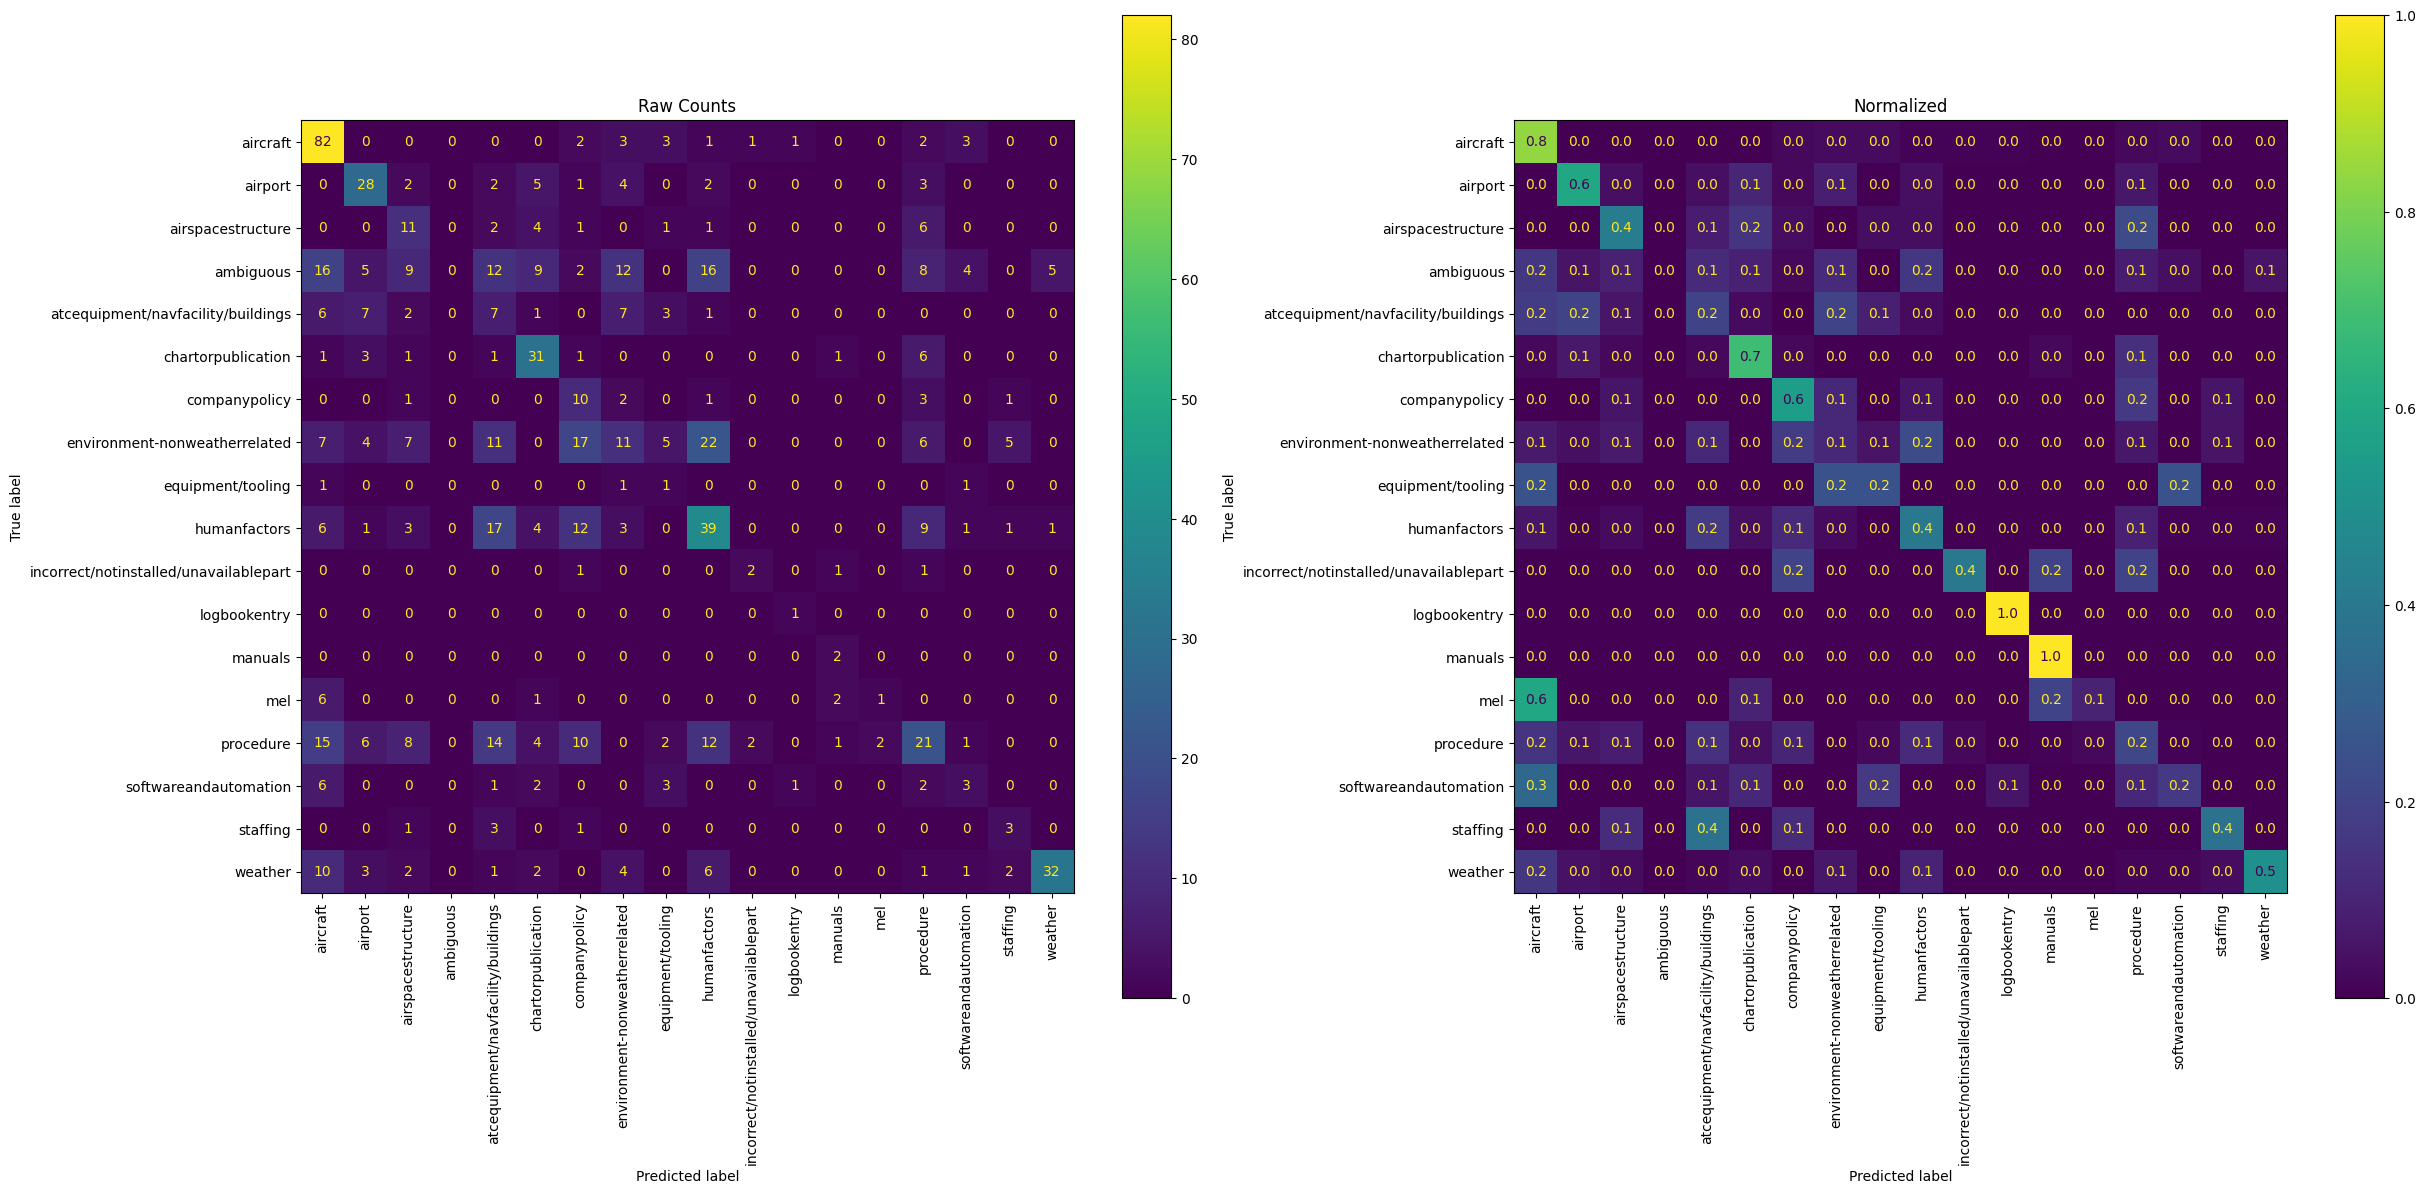

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 12))

ConfusionMatrixDisplay.from_predictions(
    joined['y_true'],
    joined['pred'],
    xticks_rotation='vertical',
    ax=ax1
)
ax1.set_title("Raw Counts")

ConfusionMatrixDisplay.from_predictions(
    joined['y_true'],
    joined['pred'],
    xticks_rotation='vertical',
    normalize='true',
    values_format='.1f',
    ax=ax2
)
ax2.set_title("Normalized")

plt.tight_layout()
plt.show()
